<a href="https://colab.research.google.com/github/LiuChen-5749342/Generative-AI-and-AI-Applications/blob/main/Task_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Phase 1: Environment Setup & Data Loading**
Imports: Bring in necessary libraries (torch, torch.nn, torch.optim, torchvision.datasets, torchvision.transforms, and matplotlib.pyplot for visualization).

Transformations: Define a simple pipeline, primarily converting the PIL images to PyTorch tensors (transforms.ToTensor()).

Dataset Instantiation: * This is where the drop-in replacement happens. We will call torchvision.datasets.FashionMNIST instead of MNIST for both training (train=True) and testing (train=False).

DataLoaders: Wrap both datasets in torch.utils.data.DataLoader instances to handle batching (e.g., batch_size=64) and shuffling for the training set.

In [1]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# 1. Define Transformations
# ToTensor() converts PIL images or numpy arrays to FloatTensors
# and automatically scales the pixel values from [0, 255] to [0.0, 1.0].
transform = transforms.Compose([
    transforms.ToTensor()
])

# 2. Download and Load Datasets
# Notice the drop-in replacement: datasets.FashionMNIST instead of datasets.MNIST
train_dataset = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# 3. Create DataLoaders
# DataLoaders handle the heavy lifting of batching the data and feeding it to the model.
batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True # Shuffling prevents the model from learning sequence-based biases during training
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False # No need to shuffle test data, we just want to evaluate it
)

# Optional sanity check to verify the shape of our data batches
if __name__ == "__main__":
    train_features, train_labels = next(iter(train_loader))
    print(f"Feature batch shape: {train_features.size()}") # Expected: [64, 1, 28, 28]
    print(f"Labels batch shape: {train_labels.size()}")    # Expected: [64]

Feature batch shape: torch.Size([64, 1, 28, 28])
Labels batch shape: torch.Size([64])


# **Phase 2: Model Definition (ImageMLP)**
Architecture: Define a subclass of nn.Module.

Layers:

A flattening layer (nn.Flatten) to convert the 28x28 2D images into a 1D tensor of 784 features.

One or more hidden fully connected layers (nn.Linear) paired with non-linear activation functions (e.g., nn.ReLU).

An output layer (nn.Linear) mapping the final hidden representations to 10 output nodes (representing the 10 clothing classes).

Forward Pass: Define the forward method to sequentially pass the data through the layers. Note: We will not apply Softmax at the end because PyTorch's CrossEntropyLoss handles it internally.

In [2]:
import torch.nn as nn

class ImageMLP(nn.Module):
    def __init__(self):
        super(ImageMLP, self).__init__()

        # 1. Flatten Layer: Converts the 2D image (28x28) into a 1D vector (784)
        self.flatten = nn.Flatten()

        # 2. Fully Connected Layers: The core of the MLP
        self.network = nn.Sequential(
            # First hidden layer: 784 inputs -> 128 nodes
            nn.Linear(784, 128),
            nn.ReLU(),

            # Second hidden layer: 128 nodes -> 64 nodes
            nn.Linear(128, 64),
            nn.ReLU(),

            # Output layer: 64 nodes -> 10 output classes (one for each clothing type)
            nn.Linear(64, 10)
        )

    def forward(self, x):
        # Pass the input through the flatten layer
        x = self.flatten(x)

        # Pass the flattened data through the sequential network
        logits = self.network(x)

        # We return raw logits (unnormalized scores).
        # We do NOT apply Softmax here because PyTorch's CrossEntropyLoss handles it.
        return logits

# Instantiate the model
model = ImageMLP()

# Optional sanity check to see the model architecture
if __name__ == "__main__":
    print(model)

ImageMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)


# **Phase 3: Training Setup & Loop**
Initialization: Instantiate the ImageMLP model.

Loss Function: Initialize nn.CrossEntropyLoss()—the standard for multi-class classification.

Optimizer: Initialize torch.optim.Adam(), passing in the model's parameters and a standard learning rate (e.g., 0.001).

The Loop (10 Epochs):

Set the model to training mode (model.train()).

Iterate over the training DataLoader.

Perform the forward pass to get predictions.

Compute the loss against the true labels.

Zero the gradients (optimizer.zero_grad()).

Perform the backward pass to calculate gradients (loss.backward()).

Update model weights (optimizer.step()).

In [4]:
import torch
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 10

# Arrays to keep track of losses for later analysis or plotting
train_losses = []
val_losses = [] # This is your validation loss tracker

print("Starting Training...")
for epoch in range(epochs):
    # -------------------------
    #     TRAINING PHASE
    # -------------------------
    model.train() # Set model to training mode
    running_train_loss = 0.0

    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # -------------------------
    #    VALIDATION PHASE
    # -------------------------
    model.eval() # Set model to evaluation mode (disables dropout/batchnorm if you add them later)
    running_val_loss = 0.0

    # torch.no_grad() disables gradient tracking, saving memory and speeding up computation
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item()

    avg_val_loss = running_val_loss / len(test_loader)
    val_losses.append(avg_val_loss)

    # Print both losses for comparison
    print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

print("Training Complete!")

Starting Training...
Epoch [1/10] | Train Loss: 0.2392 | Val Loss: 0.3447
Epoch [2/10] | Train Loss: 0.2296 | Val Loss: 0.3239
Epoch [3/10] | Train Loss: 0.2223 | Val Loss: 0.3295
Epoch [4/10] | Train Loss: 0.2152 | Val Loss: 0.3387
Epoch [5/10] | Train Loss: 0.2082 | Val Loss: 0.3433
Epoch [6/10] | Train Loss: 0.2025 | Val Loss: 0.3367
Epoch [7/10] | Train Loss: 0.1964 | Val Loss: 0.3479
Epoch [8/10] | Train Loss: 0.1916 | Val Loss: 0.3447
Epoch [9/10] | Train Loss: 0.1868 | Val Loss: 0.3567
Epoch [10/10] | Train Loss: 0.1837 | Val Loss: 0.3543
Training Complete!


# **Phase 4: Evaluation**
Set the model to evaluation mode (model.eval()).

Use the torch.no_grad() context manager to disable gradient tracking (saving memory and compute).

Iterate over the test DataLoader, pass the images through the model, and use torch.argmax to find the predicted class index.

Compare predictions to actual labels to calculate and print the final accuracy percentage on the 10,000 test images.

In [5]:
import torch

# 1. Set the model to evaluation mode
# This ensures that any layers like Dropout or BatchNorm (if added later)
# behave correctly for inference rather than training.
model.eval()

correct_predictions = 0
total_predictions = 0

# 2. Disable gradient tracking
# We don't need to backpropagate, so this saves memory and speeds up the calculation.
with torch.no_grad():
    for images, labels in test_loader:
        # Forward pass
        outputs = model(images)

        # outputs is a tensor of shape [batch_size, 10] containing raw logits.
        # torch.max returns a tuple: (maximum_values, indices_of_those_values).
        # We only care about the indices (which represent the predicted class 0-9).
        # We check along dimension 1 (the class dimension).
        _, predicted = torch.max(outputs.data, 1)

        # Add the number of images in this batch to the total
        total_predictions += labels.size(0)

        # Compare predictions to actual labels.
        # (predicted == labels) creates a boolean tensor.
        # .sum().item() counts the True values and converts it to a standard Python number.
        correct_predictions += (predicted == labels).sum().item()

# 3. Calculate and print the final accuracy
accuracy = 100 * correct_predictions / total_predictions
print(f"Final Accuracy on the 10,000 test images: {accuracy:.2f}%")

Final Accuracy on the 10,000 test images: 88.61%


# **Phase 5: Visualization**
Class Mapping: Define a dictionary or list mapping the output indices (0-9) to their actual Fashion-MNIST string labels (e.g., 'T-shirt/top', 'Trouser', 'Pullover', etc.).

Inference: Run a single batch of test images through the model.

Plotting: Use matplotlib to plot a grid of images.

Display the image.

Set the title to show: Predicted: [Class] | Actual: [Class].

Color-code the titles (e.g., green for correct predictions, red for incorrect ones) to easily highlight where the MLP struggled.

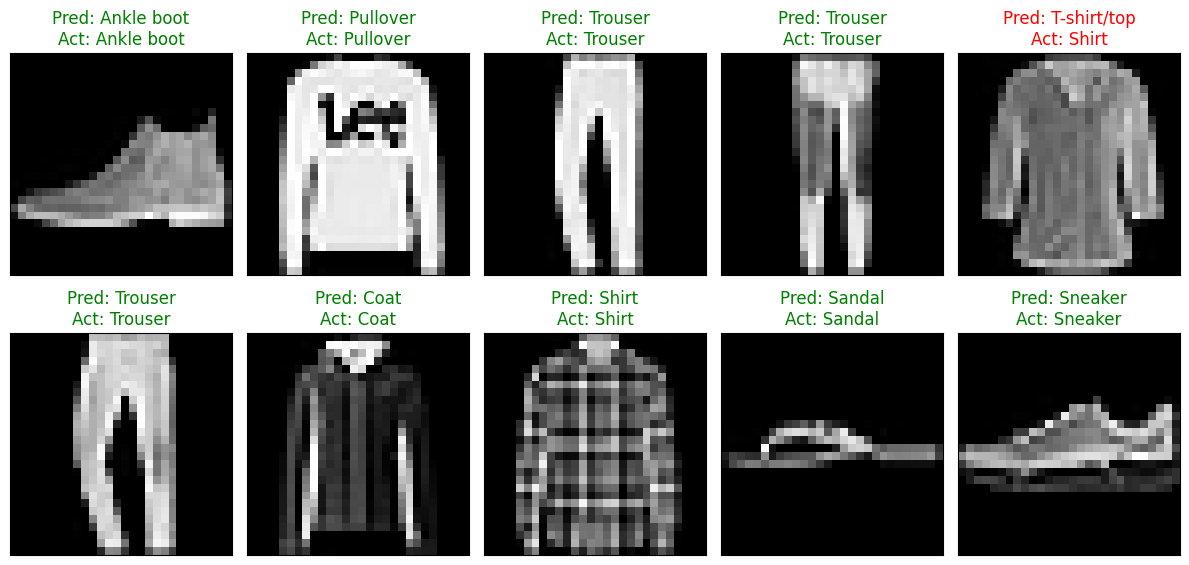

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# 1. Map the numeric labels to their actual clothing names
# These are the standard 10 classes defined by the Fashion-MNIST creators
classes = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

# 2. Grab a single batch of data from the test set
dataiter = iter(test_loader)
images, labels = next(dataiter)

# 3. Get predictions for this batch
model.eval()
with torch.no_grad():
    outputs = model(images)
    _, preds = torch.max(outputs, 1)

# 4. Set up the matplotlib figure
fig = plt.figure(figsize=(12, 6))

# Loop through the first 10 images in our batch
for idx in range(10):
    # Create a 2x5 grid of subplots
    ax = fig.add_subplot(2, 5, idx + 1, xticks=[], yticks=[])

    # PyTorch tensors are [C, H, W] (1, 28, 28).
    # Matplotlib expects [H, W] for grayscale. We use squeeze() to remove the channel dimension.
    img = images[idx].squeeze().numpy()
    ax.imshow(img, cmap='gray')

    # 5. Color-code the results
    # Green text for correct predictions, Red text for incorrect ones
    is_correct = preds[idx] == labels[idx]
    color = "green" if is_correct else "red"

    # Display the predicted and actual classes
    ax.set_title(f"Pred: {classes[preds[idx]]}\nAct: {classes[labels[idx]]}", color=color)

plt.tight_layout()
plt.show()